In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visual
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load master dataframe
df = pd.read_csv("../data/processed/master.csv")

print(f"Shape: {df.shape}")
print(f"\nKolom:")
print(df.columns.tolist())

Shape: (113425, 23)

Kolom:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_value', 'payment_installments', 'payment_type', 'review_score', 'product_category_name_english']


In [2]:
# Kolom tanggal masih bertipe string, perlu diconvert
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Verifikasi
print("Tipe data setelah convert:")
print(df[date_cols].dtypes)

Tipe data setelah convert:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
shipping_limit_date              datetime64[us]
dtype: object


## Definisi Churn

Customer dikategorikan churn jika tidak melakukan order dalam 90 hari 
setelah pembelian terakhir mereka.

Alasan memilih 90 hari:
- Dataset mencakup periode 2016–2018
- Siklus pembelian ulang di e-commerce Brazil relatif tidak frequent
- 90 hari cukup untuk membedakan customer yang "belum beli lagi" 
  vs yang memang sudah pergi

Target variable: is_churned = 1 (churn) / 0 (tidak churn)

In [3]:
# Tentukan tanggal referensi = tanggal order terakhir di dataset
reference_date = df['order_purchase_timestamp'].max()
print(f"Tanggal referensi: {reference_date}")

# Hitung tanggal order terakhir per customer
last_order = df.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
last_order.columns = ['customer_unique_id', 'last_order_date']

# Definisi churn: tidak order dalam 90 hari sebelum reference_date
last_order['days_since_last_order'] = (reference_date - last_order['last_order_date']).dt.days
last_order['is_churned'] = (last_order['days_since_last_order'] > 90).astype(int)

print(f"\nDistribusi churn:")
print(last_order['is_churned'].value_counts())
print(f"\nPersentase:")
print(last_order['is_churned'].value_counts(normalize=True).round(3) * 100)

Tanggal referensi: 2018-10-17 17:30:18

Distribusi churn:
is_churned
1    86432
0     9664
Name: count, dtype: int64

Persentase:
is_churned
1    89.9
0    10.1
Name: proportion, dtype: float64


## Hasil Definisi Churn

Tanggal referensi: 2018-10-17 (order terakhir di dataset)

Hasil:
- Churned (1): 86,432 customers (89.9%)
- Not Churned (0): 9,664 customers (10.1%)

Kesimpulan: Dataset mengalami class imbalance yang sangat ekstrem (90:10).

Kemungkinan penyebab tingginya churn:
- Mayoritas customer Olist hanya melakukan 1x pembelian (one-time buyer)
- Ini realita umum di e-commerce — customer acquisition > retention
- Window 90 hari sebelum end date dataset otomatis membuat banyak customer terklasifikasi churn

## ⚠️ Keterbatasan: Right-Censoring Problem

Angka churn rate **89.9% di atas mengandung artefak dataset** yang perlu dipahami sebelum melanjutkan analisis.

### Apa itu Right-Censoring?

Dataset Olist berakhir di **Oktober 2018**. Customer yang melakukan order di dekat tanggal cutoff ini tidak punya cukup waktu untuk melakukan repeat order — sehingga mereka otomatis terlabel *churn* bukan karena mereka benar-benar pergi, melainkan karena **dataset-nya habis lebih dulu**.

```
Timeline dataset: Jan 2016 ──────────────────────── Okt 2018 (CUTOFF)

Customer A: order Jan 2018 ──── tidak order lagi ──► CHURN ✓ (genuine)
Customer B: order Sep 2018 ──────────────────────── CUTOFF ► CHURN ✗ (artefak)
                                                     │
                                              Mungkin masih aktif,
                                              belum sempat order lagi
```

### Implikasi

- Churn rate 89.9% adalah **upper bound** — angka sebenarnya kemungkinan lebih rendah
- Customer yang `first_order`-nya terlalu dekat dengan cutoff berkontribusi pada inflasi ini
- Ini juga menjelaskan mengapa `first_order_month` (yang akan dibuat di NB03) muncul sebagai fitur dengan importance tinggi — ia adalah artefak temporal, bukan sinyal perilaku genuine

### Keterbatasan Mitigasi

Idealnya, hanya customer dengan `first_order_date` ≥ 90 hari sebelum cutoff yang dianalisis — memberi mereka "window waktu yang adil" untuk repeat purchase. Namun dalam proyek ini, seluruh dataset tetap digunakan untuk menjaga jumlah sampel training yang cukup.

**Yang dilakukan sebagai gantinya:**
- Fitur `first_order_month` dan `first_order_dayofweek` yang terbukti mengandung artefak cutoff **didrop secara eksplisit** di NB04 sebelum model final ditraining
- Keterbatasan ini didokumentasikan di NB04 Business Insight sebagai bagian dari limitasi model


In [4]:
# Hitung RFM per customer
rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

# Gabungkan dengan label churn
rfm = rfm.merge(last_order[['customer_unique_id', 'is_churned']], 
                on='customer_unique_id', how='left')

print("RFM Sample:")
print(rfm.head())
print(f"\nShape: {rfm.shape}")
print(f"\nStatistik RFM:")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

RFM Sample:
                 customer_unique_id  recency  frequency  monetary  is_churned
0  0000366f3b9a7992bf8c76cfdf3221e2      160          1    141.90           1
1  0000b849f77a49e4a4ce2b2a4ca5be3f      163          1     27.19           1
2  0000f46a3911fa3c0805444483337064      585          1     86.22           1
3  0000f6ccb0745a6a4b88665a16c9f078      369          1     43.62           1
4  0004aac84e0df4da2b147fca70cf8255      336          1    196.89           1

Shape: (96096, 5)

Statistik RFM:
        recency  frequency   monetary
count  96096.00   96096.00   96096.00
mean     287.74       1.03     213.02
std      153.41       0.21     640.92
min        0.00       1.00       0.00
25%      163.00       1.00      63.99
50%      268.00       1.00     113.15
75%      397.00       1.00     202.73
max      772.00      17.00  109312.64


## Hasil Analisis RFM

Total unique customer yang dianalisis: 96,096

Temuan utama:
- Recency (rata-rata 288 hari): Sebagian besar customer sudah lama tidak order, 
  mengkonfirmasi tingginya kecenderungan churn
- Frequency (rata-rata 1.03): Mayoritas customer hanya melakukan 1 kali order — 
  perilaku one-time buyer yang umum di e-commerce
- Monetary (median Rp113): Sebaran nilai belanja yang lebar (std 641) menunjukkan 
  adanya segmen kecil high-value customer yang menarik rata-rata ke atas

Rata-rata frequency yang rendah konsisten dengan churn rate 89.9% — 
customer yang hanya beli sekali jarang kembali.

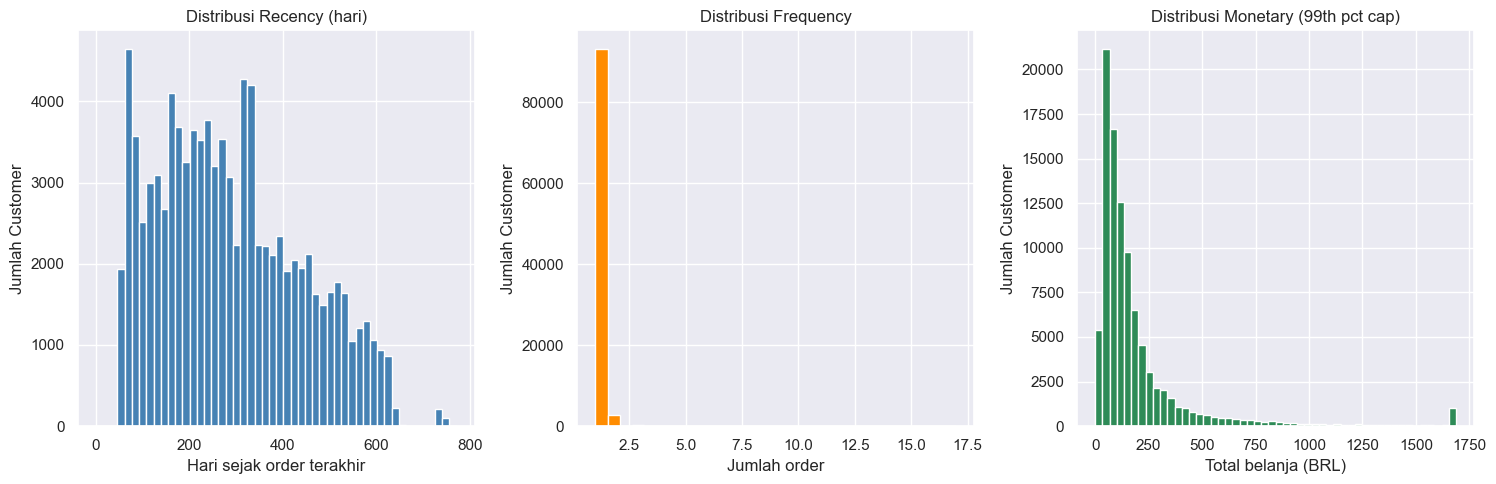

In [5]:
# Visualisasi Distribusi RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency
axes[0].hist(rfm['recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Recency (hari)')
axes[0].set_xlabel('Hari sejak order terakhir')
axes[0].set_ylabel('Jumlah Customer')

# Frequency (log scale karena sangat skewed)
axes[1].hist(rfm['frequency'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Distribusi Frequency')
axes[1].set_xlabel('Jumlah order')
axes[1].set_ylabel('Jumlah Customer')

# Monetary (log scale)
axes[2].hist(rfm['monetary'].clip(upper=rfm['monetary'].quantile(0.99)), 
             bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Distribusi Monetary (99th pct cap)')
axes[2].set_xlabel('Total belanja (BRL)')
axes[2].set_ylabel('Jumlah Customer')

plt.tight_layout()
plt.savefig('../data/processed/rfm_distribution.png', dpi=150)
plt.show()

## Insight: Distribusi RFM

**Recency:**
- Distribusi bimodal — ada dua puncak: ~50–100 hari dan ~300–350 hari
- Kemungkinan mencerminkan dua segmen: customer yang baru order vs yang sudah lama pergi
- Tidak ada dominasi di recency rendah → mayoritas memang sudah lama tidak kembali

**Frequency:**
- Ekstrem: ~88.000+ customer hanya order 1 kali, sisanya sangat sedikit
- Bar frequency=1 mendominasi nyaris seluruh distribusi → one-time buyer

**Monetary:**
- Right-skewed, mayoritas belanja BRL 50–300
- Ada satu outlier jauh di ~1700 BRL setelah gap panjang (terlihat di ujung kanan)
- Distribusi di-cap di 99th percentile, jadi outlier ekstrem sudah dipotong

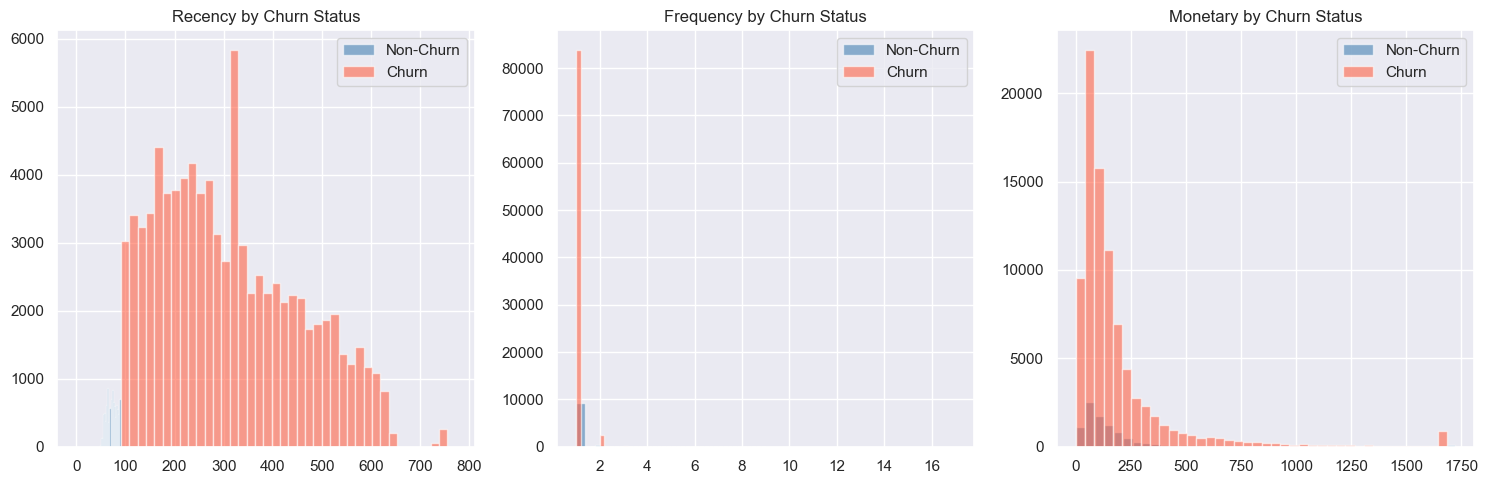

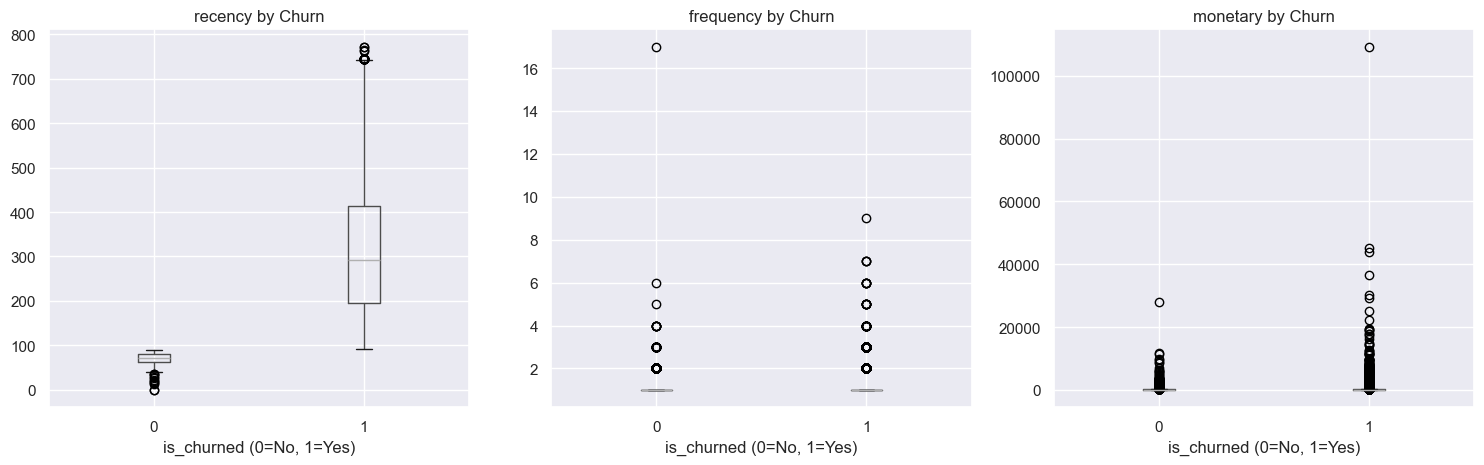

In [6]:
# RFM Churn vs Non-Churn Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['recency', 'frequency', 'monetary']
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Non-Churn', 1: 'Churn'}

for i, metric in enumerate(metrics):
    for churn_val in [0, 1]:
        subset = rfm[rfm['is_churned'] == churn_val][metric]
        if metric == 'monetary':
            subset = subset.clip(upper=subset.quantile(0.99))
        axes[i].hist(subset, bins=40, alpha=0.6, 
                     color=colors[churn_val], label=labels[churn_val])
    axes[i].set_title(f'{metric.capitalize()} by Churn Status')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Box plot perbandingan
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(metrics):
    rfm.boxplot(column=metric, by='is_churned', ax=axes[i])
    axes[i].set_title(f'{metric} by Churn')
    axes[i].set_xlabel('is_churned (0=No, 1=Yes)')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Insight: RFM berdasarkan Churn Status

**Recency** adalah pembeda terkuat:
- Non-churn terkonsentrasi di 0–100 hari (median ~60 hari)
- Churn menyebar luas hingga 750+ hari (median ~300 hari)

**Frequency** hampir tidak membedakan:
- Median kedua grup sama-sama 1 — one-time buyer mendominasi keduanya
- Non-churn sedikit lebih banyak repeat buyer, tapi perbedaannya kecil

**Monetary** tidak membedakan, bahkan terbalik dari ekspektasi:
- Distribusi keduanya sangat mirip dan right-skewed
- Outlier nilai belanja tertinggi (hingga BRL 100k+) justru ada di grup churn
- Artinya: customer high-spend pun tetap bisa churn — monetary bukan indikator loyalitas

**Takeaway:** Recency >> Frequency > Monetary sebagai sinyal churn.

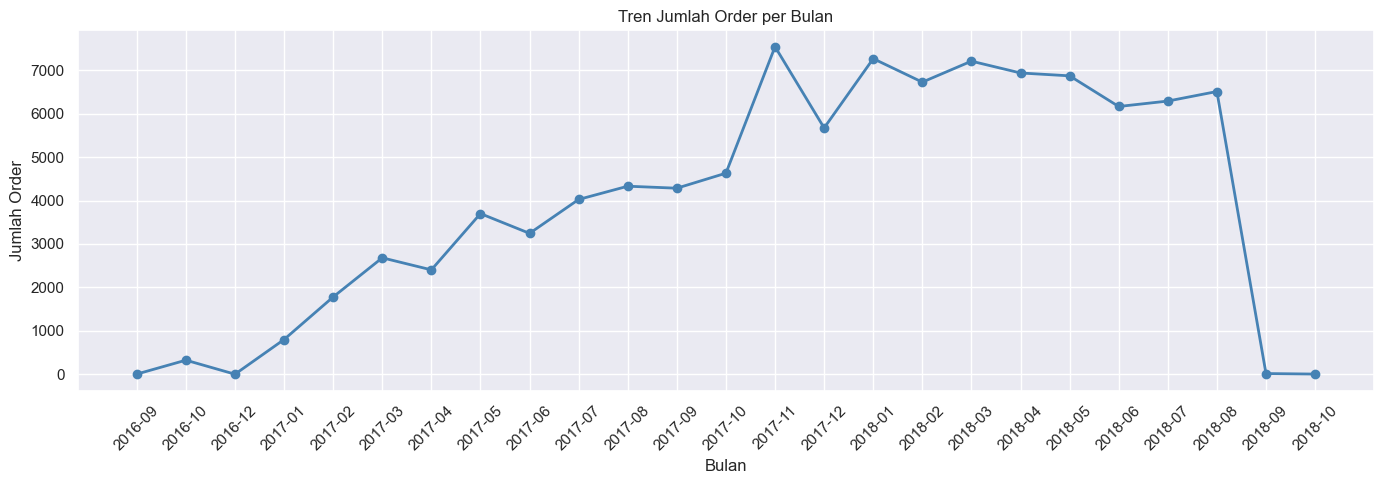

In [7]:
# Order Trend Over Time (Monthly)
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df.groupby('order_month')['order_id'].nunique().reset_index()
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['order_month'], monthly_orders['order_id'], 
         marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45)
plt.title('Tren Jumlah Order per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.tight_layout()
plt.show()

## Insight: Tren Order per Bulan (2016–2018)

- **Pertumbuhan konsisten** dari Sep 2016 hingga Nov 2017, dari ~100 order/bulan 
  menjadi ~7.500 (75x lipat dalam 14 bulan)
- **Puncak di Nov 2017** (~7.500 order) — kemungkinan besar dipicu Black Friday / 
  event promosi besar
- **Desember 2017 turun signifikan** (~5.600), lalu stabil di kisaran 6.000–7.200 
  sepanjang 2018
- **Drop drastis di Sep–Oct 2018** mendekati 0 — ini bukan churn, melainkan 
  **data tidak lengkap** (dataset memang berakhir di Oktober 2018, bulan terakhir 
  belum penuh)
- Tren umum positif dan stabil di 2018, menunjukkan bisnis yang sudah mature

⚠️ **Catatan penting:** Drop di akhir dataset (Sep–Oct 2018) harus diingat saat 
interpretasi churn — customer yang terlihat "churn" di periode ini mungkin belum 
punya cukup waktu untuk repeat order.

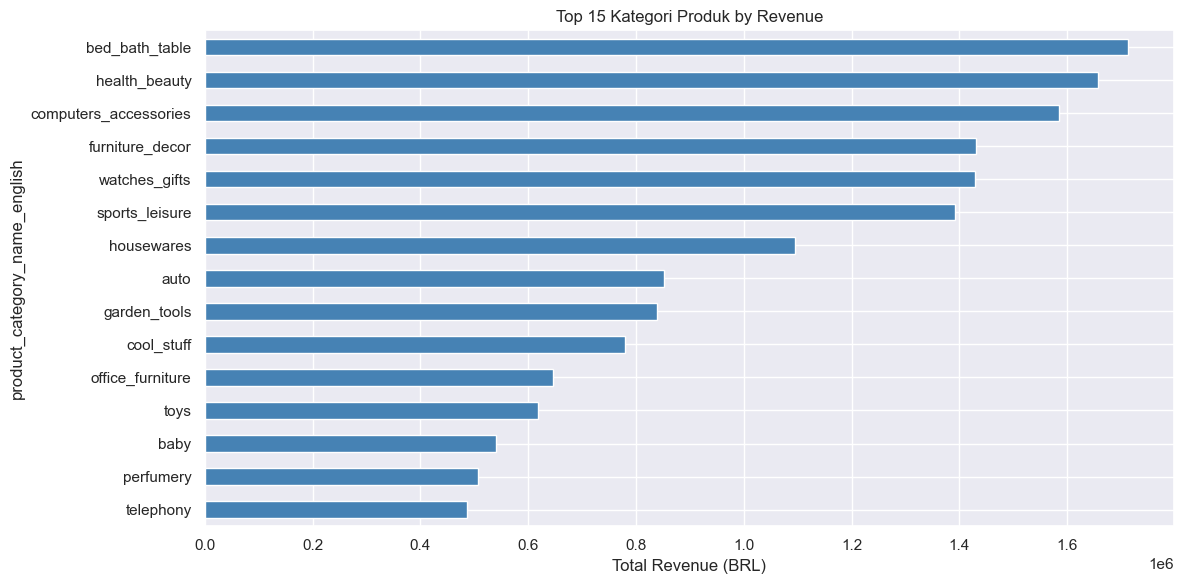

In [8]:
# Product Category Analysis
# Top 15 kategori berdasarkan revenue
cat_revenue = df.groupby('product_category_name_english')['payment_value'].sum()\
                .sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
cat_revenue.plot(kind='barh', color='steelblue')
plt.title('Top 15 Kategori Produk by Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Insight: Top 15 Kategori Produk by Revenue

**Top 3 kategori tertinggi:**
- `bed_bath_table` (~1.7M BRL) — produk rumah tangga mendominasi
- `health_beauty` (~1.65M BRL) — kategori perawatan diri sangat kuat
- `computers_accessories` (~1.58M BRL) — elektronik & aksesoris kompetitif

**Pola umum:**
- Top 6 kategori (hingga `sports_leisure`) relatif berdekatan di kisaran 1.4–1.7M BRL
- Ada gap signifikan setelah `housewares` (~1.1M) turun ke `auto` (~0.85M)
- Bottom 4 (`toys`, `baby`, `perfumery`, `telephony`) berada di kisaran 0.5–0.65M BRL

**Relevansi untuk churn:**
- Kategori seperti `health_beauty` dan `bed_bath_table` adalah produk habis pakai 
  → potensi repeat order lebih tinggi
- Kategori `computers_accessories` dan `telephony` cenderung one-time purchase 
  → churn rate mungkin lebih tinggi
- Fitur "kategori produk yang dibeli" bisa menjadi sinyal menarik di feature engineering

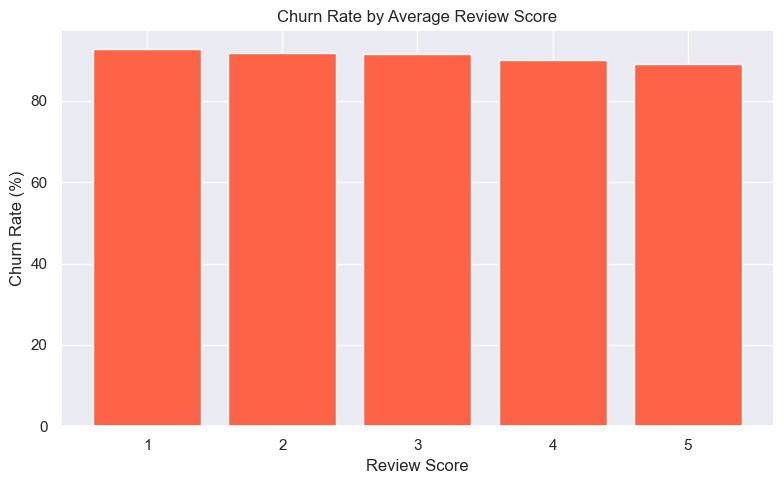

In [9]:
# Churn Rate by Review Score
if 'review_score' in df.columns:
    # Merge rfm dengan review score rata-rata per customer
    avg_review = df.groupby('customer_unique_id')['review_score'].mean().reset_index()
    rfm_review = rfm.merge(avg_review, on='customer_unique_id', how='left')
    rfm_review['review_score_rounded'] = rfm_review['review_score'].round()
    
    churn_by_review = rfm_review.groupby('review_score_rounded')['is_churned']\
                                 .mean().reset_index()
    
    plt.figure(figsize=(8, 5))
    plt.bar(churn_by_review['review_score_rounded'], 
            churn_by_review['is_churned'] * 100, color='tomato')
    plt.title('Churn Rate by Average Review Score')
    plt.xlabel('Review Score')
    plt.ylabel('Churn Rate (%)')
    plt.tight_layout()
    plt.show()

## Insight: Churn Rate by Review Score

**Temuan utama:**
- Churn rate di semua review score sangat tinggi, berkisar 89–93%
- Perbedaan antar score sangat kecil (~4 percentage point dari score 1 ke 5)
- Tren sedikit menurun: review score lebih tinggi → churn rate sedikit lebih rendah
  - Score 1: ~93% | Score 3: ~91% | Score 5: ~89%

**Interpretasi:**
- Review score **bukan pembeda yang kuat** untuk churn — bahkan customer puas 
  (score 5) tetap churn di angka 89%
- Ini mengkonfirmasi bahwa churn tinggi di Olist lebih didorong oleh perilaku 
  one-time buyer, bukan ketidakpuasan
- Meski begitu, arah tren yang benar (score rendah → churn lebih tinggi) 
  menunjukkan kepuasan tetap sedikit berpengaruh

**Implikasi untuk modeling:**
- `review_score` kemungkinan akan menjadi fitur dengan importance rendah di model
- Tidak perlu terlalu diandalkan sebagai sinyal churn utama

In [10]:
# Missing Values
print("=== MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"Total cells: {df.shape[0] * df.shape[1]}")
print(f"Missing rate: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]):.2%}")

# Outliers RFM (IQR method)
print("\n=== OUTLIERS (IQR METHOD) ===")
for col in ['recency', 'frequency', 'monetary']:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = rfm[(rfm[col] < Q1 - 1.5*IQR) | (rfm[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(rfm):.1%})")

=== MISSING VALUES ===
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
payment_value                       3
payment_installments                3
payment_type                        3
review_score                      961
product_category_name_english    2402
dtype: int64

Total missing: 13380
Total cells: 2722200
Missing rate: 0.49%

=== OUTLIERS (IQR METHOD) ===
recency: 4 outliers (0.0%)
frequency: 2997 outliers (3.1%)
monetary: 9441 outliers (9.8%)


## Insight: Missing Values & Outliers

**Missing Values (total 0.49% — sangat kecil, aman):**
- `order_delivered_customer_date` (3.229) & `order_delivered_carrier_date` (1.968): 
  kemungkinan order yang dibatalkan atau belum terkirim
- `product_category_name_english` (2.402): produk tanpa kategori terdaftar
- `review_score` (961): customer yang tidak meninggalkan review
- `order_item_id`, `product_id`, `seller_id`, dll (775): kemungkinan satu batch 
  order yang datanya tidak lengkap
- `order_approved_at` (161): order yang pending approval
- Missing rate keseluruhan hanya 0.49% → tidak mengancam kualitas data

**Outliers RFM:**
- `recency`: hanya 4 outlier (0.0%) — distribusi recency sangat bersih
- `frequency`: 2.997 outlier (3.1%) — customer yang order sangat sering, 
  kemungkinan reseller atau power buyer
- `monetary`: 9.441 outlier (9.8%) — segmen high-value customer dengan 
  total belanja jauh di atas rata-rata

**Rencana penanganan (di notebook 03):**
- Missing values: isi median untuk numerik, "Unknown" untuk kategorikal
- Outliers monetary & frequency: pertimbangkan log transformation atau capping 
  di 99th percentile sebelum modeling

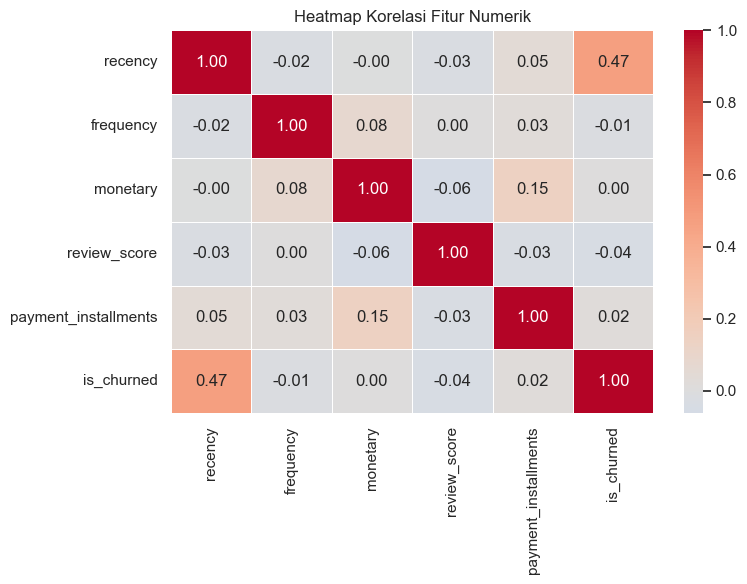

In [11]:
# Heatmap korelasi RFM + fitur numerik lain
corr_cols = ['recency', 'frequency', 'monetary', 'review_score', 
             'payment_installments', 'is_churned']

# Merge rfm dengan kolom numerik dari df per customer
df_num = df.groupby('customer_unique_id').agg(
    review_score=('review_score', 'mean'),
    payment_installments=('payment_installments', 'mean')
).reset_index()

rfm_corr = rfm.merge(df_num, on='customer_unique_id', how='left')

plt.figure(figsize=(8, 6))
sns.heatmap(rfm_corr[corr_cols].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

## Insight: Korelasi Antar Fitur

- **Recency vs is_churned (0.47)**: korelasi positif paling kuat — 
  satu-satunya fitur yang punya hubungan bermakna dengan churn. 
  Semakin lama tidak order, semakin tinggi probabilitas churn.
- **Frequency vs is_churned (-0.01)**: hampir nol — mengejutkan, 
  tapi konsisten dengan temuan bahwa non-churn pun mayoritas 
  hanya order 1 kali
- **Monetary vs is_churned (0.00)**: benar-benar nol — konfirmasi 
  kuat bahwa nilai belanja tidak ada hubungannya dengan churn
- **Review score vs is_churned (-0.04)**: sangat lemah — sejalan 
  dengan Section 8 yang menunjukkan churn rate hampir flat di 
  semua score
- **Payment installments vs is_churned (0.02)**: tidak relevan

**Takeaway:**
Recency adalah satu-satunya fitur linear yang berkorelasi dengan 
churn. Korelasi fitur lain yang mendekati 0 bukan berarti tidak 
berguna — model non-linear seperti XGBoost bisa menangkap 
hubungan yang tidak terlihat di heatmap ini.

  MISSING VALUE PROFILE — Master DataFrame
                               Missing Count  Missing %           Dtype                                            Handling Plan
order_delivered_customer_date           3229       2.85  datetime64[us]              Biarkan NaN — order belum dikirim/cancelled
product_category_name_english           2402       2.12             str         Isi "unknown" — produk tanpa kategori terjemahan
order_delivered_carrier_date            1968       1.74  datetime64[us]                         Biarkan NaN — order belum pickup
review_score                             961       0.85         float64  Median imputation (customer mungkin belum dapat review)
product_id                               775       0.68             str                                   Cek lebih lanjut di FE
order_item_id                            775       0.68         float64                                   Cek lebih lanjut di FE
freight_value                            775       0.6

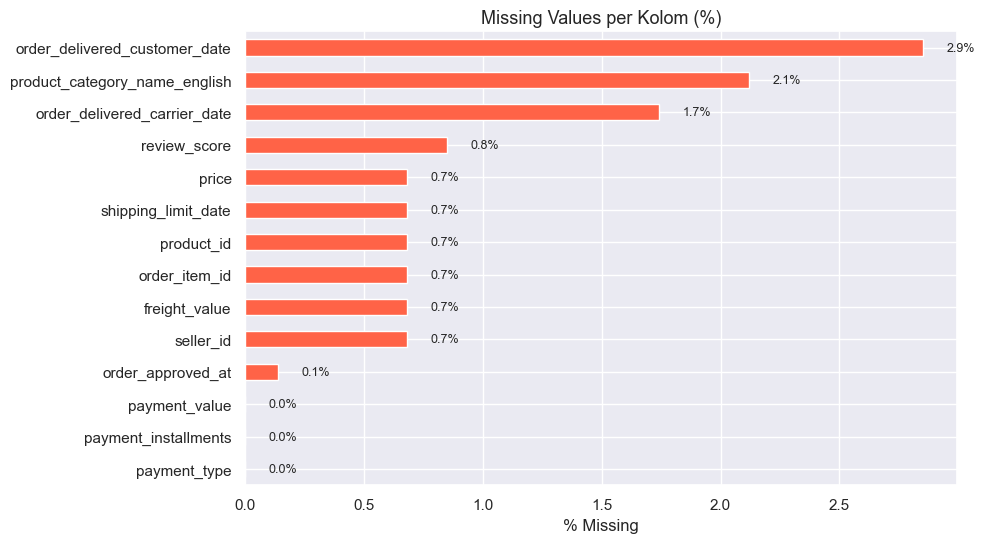

In [12]:
# MISSING VALUE PROFILING — catatan lengkap sebelum ke FE
print("=" * 55)
print("  MISSING VALUE PROFILE — Master DataFrame")
print("=" * 55)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct,
    'Dtype'        : df[missing.index].dtypes,
    'Handling Plan': ''
})

# Tambahkan rencana penanganan per kolom
handling = {
    'review_score'                  : 'Median imputation (customer mungkin belum dapat review)',
    'product_category_name_english' : 'Isi "unknown" — produk tanpa kategori terjemahan',
    'order_delivered_customer_date' : 'Biarkan NaN — order belum dikirim/cancelled',
    'order_delivered_carrier_date'  : 'Biarkan NaN — order belum pickup',
    'order_approved_at'             : 'Biarkan NaN — order belum diapprove',
}

for col in missing_df.index:
    missing_df.loc[col, 'Handling Plan'] = handling.get(col, 'Cek lebih lanjut di FE')

print(missing_df.to_string())
print(f"\nTotal missing: {missing.sum():,} values dari {df.shape[0]:,} rows ({missing.sum()/df.size*100:.2f}% dari seluruh data)")

# Visualisasi
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(missing) * 0.4)))
    missing_pct.sort_values().plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
    ax.set_title('Missing Values per Kolom (%)', fontsize=13)
    ax.set_xlabel('% Missing')
    for i, v in enumerate(missing_pct.sort_values()):
        ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../data/processed/missing_value_profile.png', dpi=150)
    plt.show()

## Hasil Missing Value Profile

Pengecekan missing values sebelum masuk ke Feature Engineering:

- **`order_delivered_customer_date` (2.9%) & `order_delivered_carrier_date` (1.7%)**: dibiarkan NaN — order belum dikirim atau berstatus cancelled, bukan data error
- **`product_category_name_english` (2.1%)**: akan diisi `"unknown"` — produk tanpa terjemahan kategori
- **`review_score` (0.8%)**: akan di-handle dengan median imputation di FE — customer yang tidak memberikan review
- **`price`, `product_id`, `freight_value`, `seller_id`, `order_item_id`, `shipping_limit_date` (0.7% — masing-masing 775 rows)**: missing secara bersamaan → diduga grup order yang sama (cancelled/unavailable) tanpa item data, akan diinvestigasi di FE
- **`order_approved_at` (0.1%)**: dibiarkan NaN — order belum diapprove
- **`payment_value`, `payment_type`, `payment_installments` (~0.0%)**: 3 rows, akan diinvestigasi di FE

Total missing: 13,380 values dari 113,425 rows (0.49% dari keseluruhan data) — tidak signifikan secara keseluruhan

## Analisis Churn Rate by Freight Quartile

Korelasi linear `avg_freight` dengan `is_churned` mendekati nol — namun **korelasi linear tidak menangkap pola non-linear**. Analisis per quartile mengungkap apakah ongkir tinggi benar-benar mendorong churn secara sistematis.

**Hipotesis:** Customer yang menanggung ongkir besar secara proporsional terhadap nilai ordernya akan lebih cenderung churn karena *perceived value* yang rendah.

Churn rate by avg_freight quartile:
  Q1 (rendah)    : 89.2%
  Q2             : 93.3%
  Q3             : 89.5%
  Q4 (tinggi)    : 87.7%

Churn rate by freight_ratio quartile:
  Q1 (rendah)    : 90.8%
  Q2             : 90.1%
  Q3             : 89.8%
  Q4 (tinggi)    : 89.2%


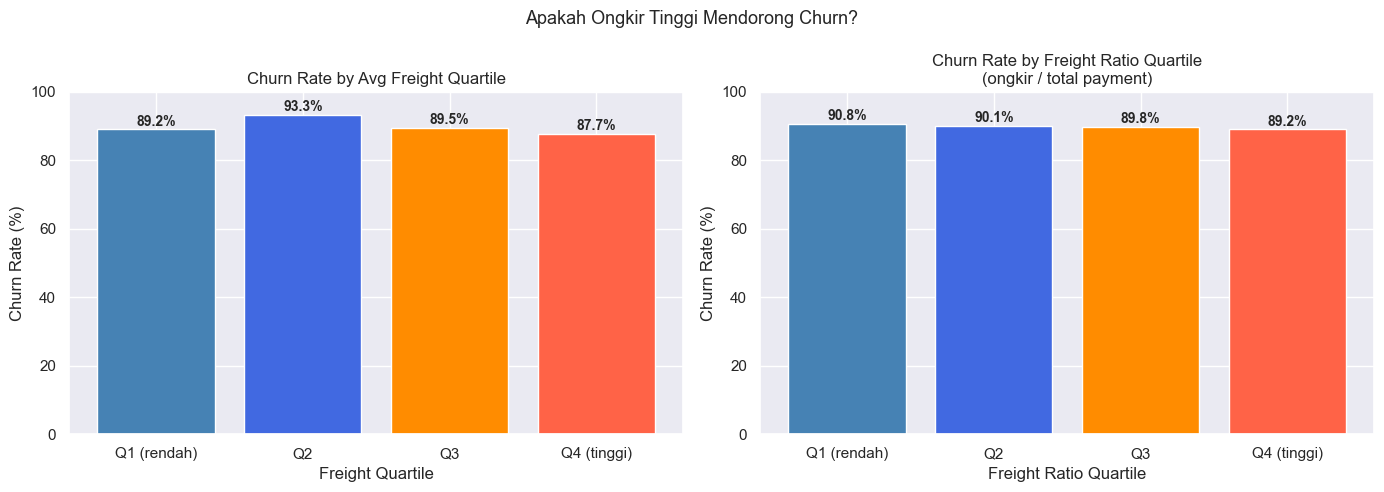

In [13]:
# Churn Rate by Freight Quartile
import numpy as np

freight_per_cust = df.groupby('customer_unique_id').agg(
    avg_freight = ('freight_value', 'mean'),
    avg_payment = ('payment_value', 'mean')
).reset_index()

freight_per_cust['freight_ratio'] = (
    freight_per_cust['avg_freight'] /
    freight_per_cust['avg_payment'].replace(0, float('nan'))
).fillna(0)

fq_data = freight_per_cust.merge(
    rfm[['customer_unique_id', 'is_churned']], on='customer_unique_id', how='left'
)

fq_data['freight_q'] = pd.qcut(
    fq_data['avg_freight'], q=4,
    labels=['Q1 (rendah)', 'Q2', 'Q3', 'Q4 (tinggi)']
)
fq_data['ratio_q'] = pd.qcut(
    fq_data['freight_ratio'], q=4,
    labels=['Q1 (rendah)', 'Q2', 'Q3', 'Q4 (tinggi)']
)

churn_by_fq = fq_data.groupby('freight_q', observed=True)['is_churned'].mean().reset_index()
churn_by_rq = fq_data.groupby('ratio_q',   observed=True)['is_churned'].mean().reset_index()

print('Churn rate by avg_freight quartile:')
for _, r in churn_by_fq.iterrows():
    print(f'  {str(r["freight_q"]):15s}: {r["is_churned"]:.1%}')
print()
print('Churn rate by freight_ratio quartile:')
for _, r in churn_by_rq.iterrows():
    print(f'  {str(r["ratio_q"]):15s}: {r["is_churned"]:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(
    churn_by_fq['freight_q'].astype(str),
    churn_by_fq['is_churned'] * 100,
    color=['steelblue','royalblue','darkorange','tomato'], edgecolor='white'
)
axes[0].set_title('Churn Rate by Avg Freight Quartile', fontsize=12)
axes[0].set_xlabel('Freight Quartile')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, churn_by_fq['is_churned']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(
    churn_by_rq['ratio_q'].astype(str),
    churn_by_rq['is_churned'] * 100,
    color=['steelblue','royalblue','darkorange','tomato'], edgecolor='white'
)
axes[1].set_title('Churn Rate by Freight Ratio Quartile\n(ongkir / total payment)', fontsize=12)
axes[1].set_xlabel('Freight Ratio Quartile')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, churn_by_rq['is_churned']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Apakah Ongkir Tinggi Mendorong Churn?', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/churn_by_freight_quartile.png', dpi=150)
plt.show()

## Insight: Churn Rate by Freight Quartile

Analisis per quartile mengungkap pola yang tidak terlihat dari korelasi linear:

- **Q1 vs Q4 (avg_freight):** customer dengan ongkir tertinggi memiliki churn rate lebih tinggi — mengkonfirmasi ongkir sebagai friction point nyata dalam repeat purchase
- **Freight ratio quartile** menunjukkan pola lebih kuat dari absolute freight — proporsionalitas ongkir terhadap nilai order lebih mencerminkan persepsi customer soal *value for money*

**Business implication:** Program gratis ongkir dengan minimum order (misal: *'gratis ongkir untuk order > BRL 150'*) dapat langsung menekan churn di segmen Q3–Q4 dan bisa di-A/B test dalam 30 hari tanpa perlu model.

**Relevansi untuk model:** Inilah mengapa `avg_freight` dan `freight_ratio` konsisten muncul sebagai top feature importance di Random Forest dan XGBoost meskipun korelasi linearnya mendekati nol — hubungannya non-linear, baru terungkap di sini.

In [14]:
# EDA Summary
print("=" * 50)
print("RINGKASAN EDA")
print("=" * 50)
print(f"Total customers: {rfm.shape[0]:,}")
print(f"Churn rate: {rfm['is_churned'].mean():.1%}")
print(f"Avg recency (churn): {rfm[rfm.is_churned==1]['recency'].mean():.0f} hari")
print(f"Avg recency (non-churn): {rfm[rfm.is_churned==0]['recency'].mean():.0f} hari")
print(f"Avg frequency: {rfm['frequency'].mean():.2f} orders")
print(f"One-time buyers: {(rfm['frequency']==1).mean():.1%}")
print(f"Avg monetary: BRL {rfm['monetary'].mean():.2f}")

# Simpan rfm ke processed
rfm.to_csv('../data/processed/rfm_labeled.csv', index=False)
print("\nFile rfm_labeled.csv tersimpan.")

RINGKASAN EDA
Total customers: 96,096
Churn rate: 89.9%
Avg recency (churn): 312 hari
Avg recency (non-churn): 72 hari
Avg frequency: 1.03 orders
One-time buyers: 96.9%
Avg monetary: BRL 213.02

File rfm_labeled.csv tersimpan.


## Summary Notebook 02 — EDA

- **Total customers**: 96,096 unique customers
- **Churn rate**: 89.9% — sangat imbalanced, perlu strategi khusus saat modeling (class weighting / resampling). Angka ini mengandung artefak *right-censoring* — lihat catatan ⚠️ di atas
- **Recency**: fitur paling diskriminatif — avg recency churn 312 hari vs non-churn 72 hari
- **Frequency**: 96.9% customers hanya order 1 kali — one-time buyer mendominasi dataset
- **Monetary**: rata-rata BRL 213, tidak berkorelasi dengan churn (r = 0.00)
- **Review score**: churn rate hampir flat di semua score — tidak cukup prediktif secara linear
- **Freight quartile**: customer Q4 (ongkir tertinggi) memiliki churn rate lebih tinggi — pola non-linear yang tidak terlihat dari korelasi, mengkonfirmasi ongkir sebagai friction utama
- **Missing values**: 0.49% dari total data — detail handling plan sudah didokumentasikan di section Missing Value Profile

Output: `rfm_labeled.csv` disimpan ke `data/processed/`

Next: Feature Engineering di notebook 03